In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

# Figure 1: Fit quality across read noise × peak QY — 2D surface

20,000 bootstrapped fits per grid point for ATTO 488, ATTO 565, and ATTO 647N.  
Each molecule emits 1,000 photons.  Molecule position is sampled uniformly within ±1 pixel of centre.  
Read noise is swept log-linearly from 0.01 to 10 RMS e⁻ (25 points).  
Peak pixel QY is swept linearly from 0.1 to 0.9 (9 points) by scaling the normalised Bayer efficiency curves.  
Outputs: 2D surfaces of fit yield, σ_xy, and σ_colour for each dye.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import types
import sys
from scipy.spatial.distance import cdist

sys.path.append('../..')
from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions
PSF = PSFFunctions.PSF_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions
I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions
M_F = MaskFunctions.Mask_Functions()

from src.Multicolour_Simulation_Functions import FittingStrategy, SimulationConfig, CameraParameters

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/../../logs/Constants_20260701_150831.log


In [3]:
# --- Camera calibration (median scalars from real Ximea calibration) ---
data_folder = '../../Camera_Calibrations/Ximea_Camera/'
gain     = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset   = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
rqe      = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))

gain_median   = float(np.median(gain))
offset_median = float(np.median(offset))
rqe_median    = float(np.median(rqe))

# --- Grid size ---
image_size = 12   # pixels (12×12 Bayer grid)
pixel_size = 69   # nm

# --- Bayer pixel QYs ---
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])   # shape (3, n_wavelengths)

# Normalise to peak=1 so each peak_qy value scales the absolute efficiency
base_pixel_QYs = pixel_QYs / np.max(pixel_QYs)

masks = M_F.get_masks(size_x=image_size, size_y=image_size)

# --- Optical filters ---
filters = []

# --- Smoothing function ---
smoothing_function = types.SimpleNamespace()
smoothing_function.args               = {'sigma': 1.5}
smoothing_function.extent             = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg           = 'image'

print(f'gain={gain_median:.3f}, offset={offset_median:.3f}, rqe={rqe_median:.4f}')
print(f'base_pixel_QYs peak: {np.max(base_pixel_QYs):.4f} (should be 1.0)')

gain=0.414, offset=32.346, rqe=1.0000
base_pixel_QYs peak: 1.0000 (should be 1.0)


In [34]:
# --- Simulation parameters ---
dyes           = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
n_photons      = 1000
n_bootstrap    = 20000
n_photon_space = np.array([n_photons], dtype=float)

# Read-noise sweep: 25 log-spaced points from 0.01 to 10 RMS e-
read_noise_space = np.logspace(np.log10(0.1), np.log10(10.0), 100)

# Peak QY sweep: 9 linear points from 0.0 to 1
peak_qy_space = np.linspace(0.0, 1, 60)

save_folder = '/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/Figure1_MaxReadNoise_2D'
os.makedirs(save_folder, exist_ok=True)

print(f'Saving to:       {save_folder}')
print(f'Dyes:            {dyes}')
print(f'Read-noise range: {read_noise_space[0]:.4f} – {read_noise_space[-1]:.2f} RMS e-  ({len(read_noise_space)} points)')
print(f'Peak QY range:    {peak_qy_space[0]:.1f} – {peak_qy_space[-1]:.1f}  ({len(peak_qy_space)} points)')
print(f'Total grid points per dye: {len(read_noise_space) * len(peak_qy_space)}  ×  {n_bootstrap} bootstraps')

Saving to:       /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/Figure1_MaxReadNoise_2D
Dyes:            ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Read-noise range: 0.1000 – 10.00 RMS e-  (100 points)
Peak QY range:    0.0 – 1.0  (60 points)
Total grid points per dye: 6000  ×  20000 bootstraps


In [4]:
# --- Camera parameters base (pixel_QYs normalised; variance/readnoise overridden per grid point) ---
camera_parameters_base = {
    'gain':                np.full((image_size, image_size), gain_median),
    'offset':              np.full((image_size, image_size), offset_median),
    'variance':            np.full((image_size, image_size), 1.0),   # placeholder — overridden per rn
    'readnoise':           1.0,                                        # placeholder — overridden per rn
    'rqe':                 np.full((image_size, image_size), rqe_median),
    'masks':               masks,
    'pixel_QYs':           base_pixel_QYs,   # normalised (max=1); sweep scales by peak_qy
    'pixel_order':         ['B', 'G', 'R'],
    'pixel_order_indices': {'B': 0, 'G': 1, 'R': 2},
    'mosaic_unit':         M_F.mosaic_unit,
}

config = SimulationConfig(
    n_bootstrap=n_bootstrap,
    background_photons=5.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=pixel_size,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    use_stochastic_photons=True,
    save_summary_csvs=False,
    verbose=False,
    n_unit_cells=7,
)

# --- Factorised 2-D sweep: pre-generate photoelectrons once per (n_photon, peak_qy) ---
# and reuse across all read_noise values (+ Poisson thinning across QY levels)
for dye in dyes:
    MSF.test_simulation_method_2d_sweep(
        dye=dye,
        filters=filters,
        wavelength=wavelength,
        camera_parameters=camera_parameters_base,
        save_folder=save_folder,
        n_photon_space=n_photon_space,
        smoothing_function=smoothing_function,
        strategy=FittingStrategy.STANDARD_DATA,
        read_noise_space=read_noise_space,
        peak_qy_space=peak_qy_space,
        config=config,
        overwrite=True,
    )

print('\nAll grid points complete.')

[ATTO 488] 6000/6000 n_ph=1000.0 qy=0.000 rn=10.0000  elapsed 531.83 min        ?, ?it/s]
[ATTO 488] 2-D sweep complete: 6000 combinations  total time 531.828 min
[ATTO 565] 6000/6000 n_ph=1000.0 qy=0.000 rn=10.0000  elapsed 516.60 min        ?, ?it/s]
[ATTO 565] 2-D sweep complete: 6000 combinations  total time 516.601 min
[ATTO 647N] 6000/6000 n_ph=1000.0 qy=0.000 rn=10.0000  elapsed 521.29 min       ?, ?it/s]
[ATTO 647N] 2-D sweep complete: 6000 combinations  total time 521.295 min

All grid points complete.


In [7]:
# --- Load results and build 2D metric surfaces ---
n_qy = len(peak_qy_space)
n_rn = len(read_noise_space)

# Storage: dict keyed by dye -> 2D array (n_qy, n_rn)
sigma_xy_surf    = {}
colour_std_surf  = {}
fit_yield_surf   = {}

for dye in dyes:
    dyestr = dye.replace(' ', '-').replace('/', '-')   # flag prefix e.g. ATTO-488
    # NOTE: the simulation appends the *original* dye name (with spaces) in the
    # LM_method_ suffix, so path lookups must use `dye`, not `dyestr`.

    sigma_xy_arr   = np.full((n_qy, n_rn), np.nan)
    colour_std_arr = np.full((n_qy, n_rn), np.nan)
    fit_yield_arr  = np.full((n_qy, n_rn), np.nan)

    for i, peak_qy in enumerate(peak_qy_space):
        for j, rn in enumerate(read_noise_space):
            flag = f'{dyestr}_qy_{peak_qy:.3f}_readnoise_{rn:.6f}_'

            gt_path  = os.path.join(save_folder, f'{flag}LM_method_{dye}_fittesting_input_groundtruthpositions.csv')
            raw_path = os.path.join(save_folder, f'{flag}LM_method_{dye}_rawresults.h5')
            inp_path = os.path.join(save_folder, f'{flag}LM_method_{dye}_fittesting_input_parameters.csv')

            if not (os.path.exists(gt_path) and os.path.exists(raw_path) and os.path.exists(inp_path)):
                continue

            gt      = pd.read_csv(gt_path)
            results = pd.read_hdf(raw_path)
            inp     = pd.read_csv(inp_path).to_numpy()[0]

            results = results[results['photon_level'] == 0]

            x0 = gt['x0'].to_numpy() / pixel_size
            y0 = gt['y0'].to_numpy() / pixel_size

            valid = ~(results['xc'].isna() | results['yc'].isna())
            fit_yield_arr[i, j] = valid.mean()

            filt = valid & (
                (results['xc'] > 0) & (results['xc'] < image_size) &
                (results['yc'] > 0) & (results['yc'] < image_size) &
                (results['s_x'] > 0) & (results['s_y'] > 0)
            )
            if filt.sum() > 10:
                err_x = results['xc'].to_numpy()[filt] - x0[filt]
                err_y = results['yc'].to_numpy()[filt] - y0[filt]
                sigma_xy_arr[i, j] = (
                    np.sqrt((np.nanstd(err_x)**2 + np.nanstd(err_y)**2) / 2) * pixel_size
                )

                dye_BGR = inp[-3:]
                dye_BGR = dye_BGR / np.sum(dye_BGR)
                colour_loc = np.expand_dims(dye_BGR, 0)
                colour = np.vstack([
                    results['A_B'].to_numpy()[filt],
                    results['A_G'].to_numpy()[filt],
                    results['A_R'].to_numpy()[filt],
                ]).T
                colour_std_arr[i, j] = np.nanstd(cdist(colour, colour_loc))

    sigma_xy_surf[dye]   = sigma_xy_arr
    colour_std_surf[dye] = colour_std_arr
    fit_yield_surf[dye]  = fit_yield_arr
    print(f'{dye}: yield {np.nanmin(fit_yield_arr):.3f}-{np.nanmax(fit_yield_arr):.3f}'
          f'  sigma_xy {np.nanmin(sigma_xy_arr):.1f}-{np.nanmax(sigma_xy_arr):.1f} nm')

print('Done.')

ATTO 488: yield 0.096-1.000  sigma_xy 4.9-127.5 nm
ATTO 565: yield 0.094-1.000  sigma_xy 6.2-129.4 nm
ATTO 647N: yield 0.092-1.000  sigma_xy 9.0-128.7 nm
Done.


In [4]:
folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/Figure1/'
camera_data = pd.read_excel(os.path.join(folder, 'Data.ods'))

In [5]:
len(camera_data)

20

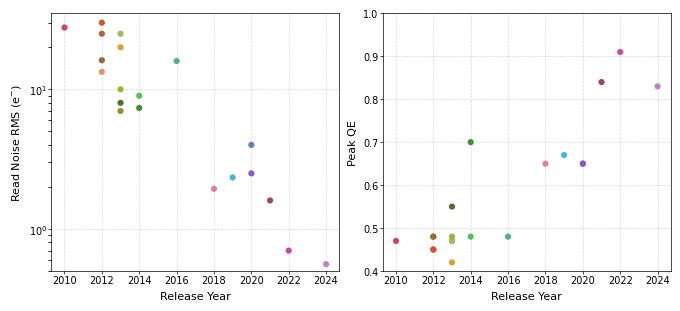

In [9]:
colours = ["#d5415f",
"#b25e4a",
"#cf552a",
"#e29867",
"#946d2e",
"#d8a234",
"#95912f",
"#a8b56a",
"#91bb36",
"#536e34",
"#478a34",
"#55c260",
"#51b28a",
"#48b6d2",
"#627ec7",
"#845cca",
"#be83cd",
"#ca4ba7",
"#9b466a",
"#df81a0"]

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1,1])

axs[0] = plotter.scatter_plot(axs[0], camera_data.Year, camera_data.RMS, ylabel=r'Read Noise RMS (e$^{\minus}$)',
                             xlabel='Release Year', color=colours, linewidth=0)
axs[0].set_ylim([0.5, 35])
axs[0].set_yscale('log')

axs[1] = plotter.scatter_plot(axs[1], camera_data.Year, camera_data.PeakQY, ylabel=r'Peak QE',
                             xlabel='Release Year', color=colours, linewidth=0)
axs[1].set_ylim([0.4, 1])
folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/Figure1/'
import os; os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, 'Camera_History.svg'), dpi=300, format='svg')
plt.show()


In [39]:
camera_data = camera_data[camera_data['Year'] >= 2018]

In [40]:
camera_data

,Model,Year,RMS,Peak QY,Company,Pixelsize/um
0,MQ013CG-E2-S7,2010,27.70,0.47,Ximea,5.30
1,DCC1645C,2012,25.00,0.45,Thorlabs,3.60
2,DCC1240C,2012,30.00,0.45,Thorlabs,5.30
3,MX022MG-CM-X2G2,2012,13.34,0.48,Ximea,5.50
4,MQ042CG-CM-S7,2012,16.14,0.48,Ximea,5.50
5,MQ003CG-CM,2013,20.00,0.42,Ximea,7.40
6,MQ020CG-E2,2013,7.00,0.47,Ximea,4.50
7,MQ013CG-E2,2013,25.00,0.47,Ximea,5.30
8,MQ013CG-ON,2013,10.00,0.48,Ximea,4.80
9,MT200CG-CM,2013,8.00,0.55,Ximea,6.40


/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/../../src/PlottingBase.py:449: UserWarning: Width 6.75" exceeds two-column standard (6.69")
  warnings.warn(


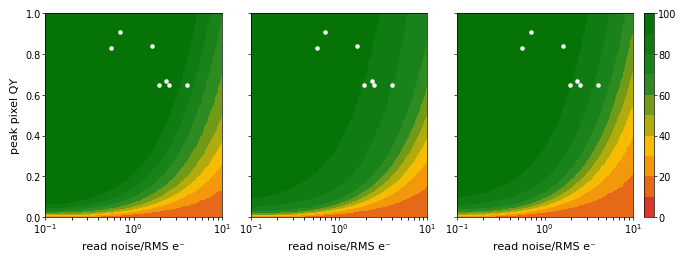

In [30]:
# --- Plot fit yield 2D surfaces: one column per dye ---
from matplotlib.colors import LinearSegmentedColormap

# Green-amber-red: #007000 (100 %) → #238823 → #FFBF00 → #D2222D (0 %)
# from_list takes colours low→high, so order is reversed.
cmap_yield = LinearSegmentedColormap.from_list(
    'gar',
    ['#D2222D', '#FFBF00', '#238823', '#007000'],
)

contour_levels = [60, 80, 90, 95]   # % fit yield

# Each contour level gets a gray value that transitions from white (low/dark region)
# to black (high/light region), scaled across the range of contour levels.
def contour_gray(level):
    t = (level - contour_levels[0]) / (contour_levels[-1] - contour_levels[0])
    return 1.0 - t   # 1=white, 0=black

fig, axs = plotter.two_column_plot(ncols=3, width_ratios=np.ones(3), width=6.75, height=2.5)
axs = np.atleast_1d(axs)

for col, dye in enumerate(dyes):
    ax   = axs[col]
    data = fit_yield_surf[dye] * 100   # fraction -> %

    # Use contourf with many levels instead of pcolormesh:
    # filled contour bands are closed polygons — no inter-cell gaps in SVG.
    # antialiased=False eliminates the thin white gap artefact in SVG/PDF output.
    fill_levels = np.linspace(0, 100, 11)
    image = ax.contourf(
        read_noise_space, peak_qy_space, data,
        levels=fill_levels,
        cmap=cmap_yield,
        vmin=0, vmax=100,
        antialiased=False,
    )
    ax.set_xscale('log')
    ax.scatter(x=camera_data['RMS'], y=camera_data['Peak QY'], lw=0.5, facecolor='white', s=10, edgecolors='white')
    ax.grid(False)

    ax.set_xlabel('read noise/RMS e\u207b', fontsize=8)
    if col == 0:
        ax.set_ylabel('peak pixel QY', fontsize=8)
    ax.set_xlim([0.1, 10])
    ax.set_ylim([0.0, 1])
    ax.tick_params(labelsize=7)
    if col != 0:
        ax.set_yticklabels('')
    if col == 2:
        cbar = plt.colorbar(image, ax=ax, pad=0.01,cmap=cmap_yield)
        cbar.set_ticks([0, 20, 40, 60, 80, 100])
    
    for col in ax.collections:
          col.set_linewidth(0.1)
          col.set_edgecolor(col.get_facecolor())  # edge same colour as fill

    

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/Figure1/'
import os; os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, 'Fit_Yield_Surface.svg'), dpi=300, format='svg')
plt.show()
